In [1]:
import pandas as pd
from sklearn.datasets import load_iris

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target  # Add target column (0, 1, 2 for species)

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Check data types and missing values
print("\nData types and missing values:")
print(df.info())
print("\nMissing values per column:")
print(df.isnull().sum())

# Clean data (no missing values in Iris, but for demonstration)
df_clean = df.dropna()  # Or use df.fillna(value)

First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   species  
0        0  
1        0  
2        0  
3        0  
4        0  

Data types and missing values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   spec

In [2]:
# Basic statistics
print("\nSummary statistics:")
print(df_clean.describe())

# Group by species and calculate mean petal length
print("\nMean petal length by species:")
print(df_clean.groupby('species')['petal length (cm)'].mean())

# Interesting finding: 
# Species 2 (virginica) has significantly longer petals than species 0 (setosa).


Summary statistics:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)     species  
count        150.000000  150.000000  
mean           1.199333    1.000000  
std            0.762238    0.819232  
min            0.100000    0.000000  
25%            0.300000    0.000000  
50%            1.300000    1.000000  
75%            1.800000    2.000000  
max            2.500000    2.000000  

Mean petal length by species:
species
0    1.462
1

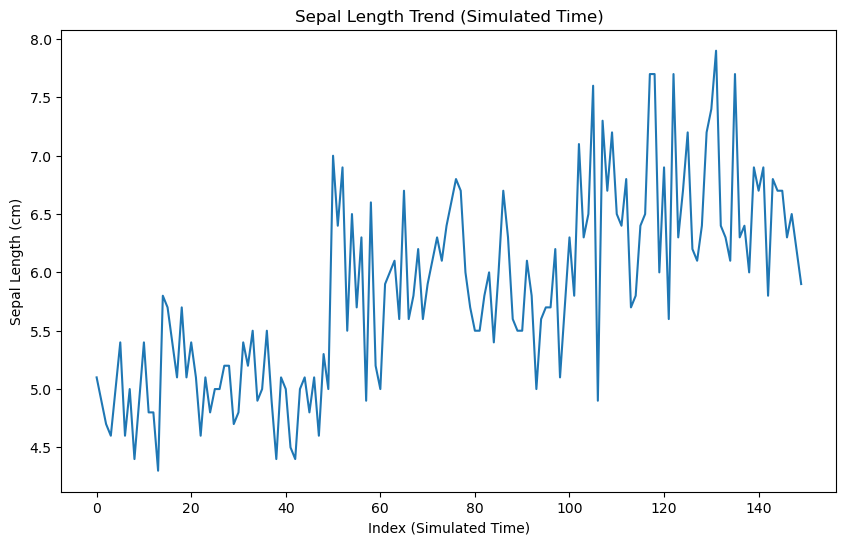

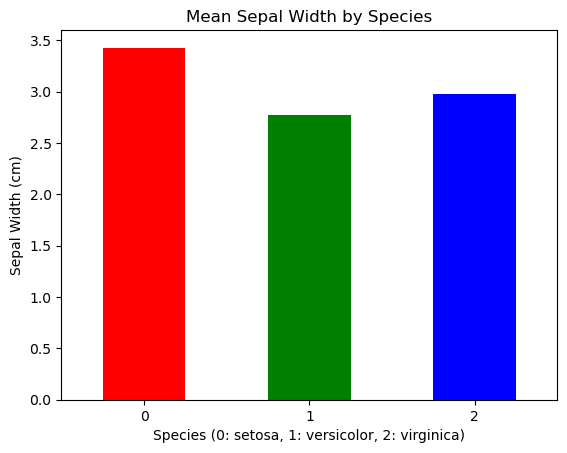

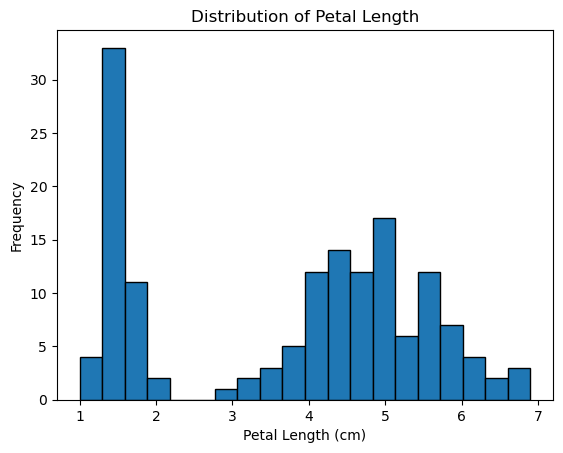

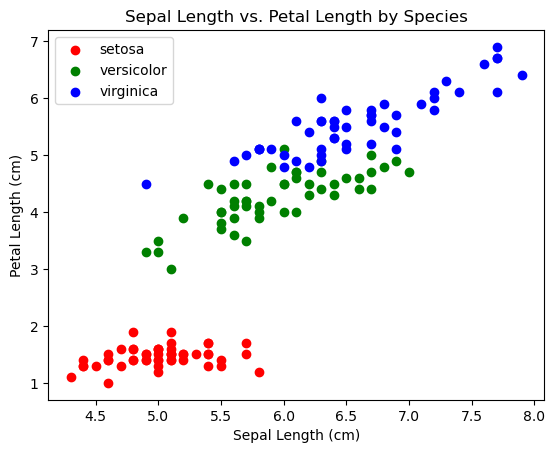

In [3]:
import matplotlib.pyplot as plt

# 1. Line chart (simulated trend over "index" as proxy for time)
plt.figure(figsize=(10, 6))
df_clean['sepal length (cm)'].plot(kind='line', title='Sepal Length Trend (Simulated Time)')
plt.xlabel('Index (Simulated Time)')
plt.ylabel('Sepal Length (cm)')
plt.show()

# 2. Bar chart (mean sepal width by species)
df_clean.groupby('species')['sepal width (cm)'].mean().plot(kind='bar', color=['red', 'green', 'blue'])
plt.title('Mean Sepal Width by Species')
plt.xlabel('Species (0: setosa, 1: versicolor, 2: virginica)')
plt.ylabel('Sepal Width (cm)')
plt.xticks(rotation=0)
plt.show()

# 3. Histogram (distribution of petal length)
plt.hist(df_clean['petal length (cm)'], bins=20, edgecolor='black')
plt.title('Distribution of Petal Length')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Frequency')
plt.show()

# 4. Scatter plot (sepal length vs. petal length)
colors = ['red', 'green', 'blue']
species_names = iris.target_names
for i in range(3):
    plt.scatter(
        df_clean[df_clean['species'] == i]['sepal length (cm)'],
        df_clean[df_clean['species'] == i]['petal length (cm)'],
        color=colors[i],
        label=species_names[i]
    )
plt.title('Sepal Length vs. Petal Length by Species')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Petal Length (cm)')
plt.legend()
plt.show()